In [12]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data")
IMG_EXTS = {".jpg", ".jpeg", ".png", 'webp'}

rows = [
    {"path": str(p), "label": p.parent.name}
    for p in DATA_DIR.rglob("*")
    if p.suffix.lower() in IMG_EXTS
]

df = pd.DataFrame(rows)
print(df.shape)
print(df["label"].value_counts())
df.head()



(545, 2)
label
full        327
half        163
overflow     55
Name: count, dtype: int64


,path,label
0,..\data\full\-on-white-background-transparent-...,full
1,..\data\full\01-waterbottlesun_20190719_0023_2...,full
2,..\data\full\0bnC0a9OdzJtymklrmne_1_11zon.jpeg,full
3,..\data\full\1-0l-fresh-water-bottle-mockup_35...,full
4,..\data\full\1000_F_181641215_ZAQ5NSDRONequztA...,full


labels: ['full', 'half', 'overflow']


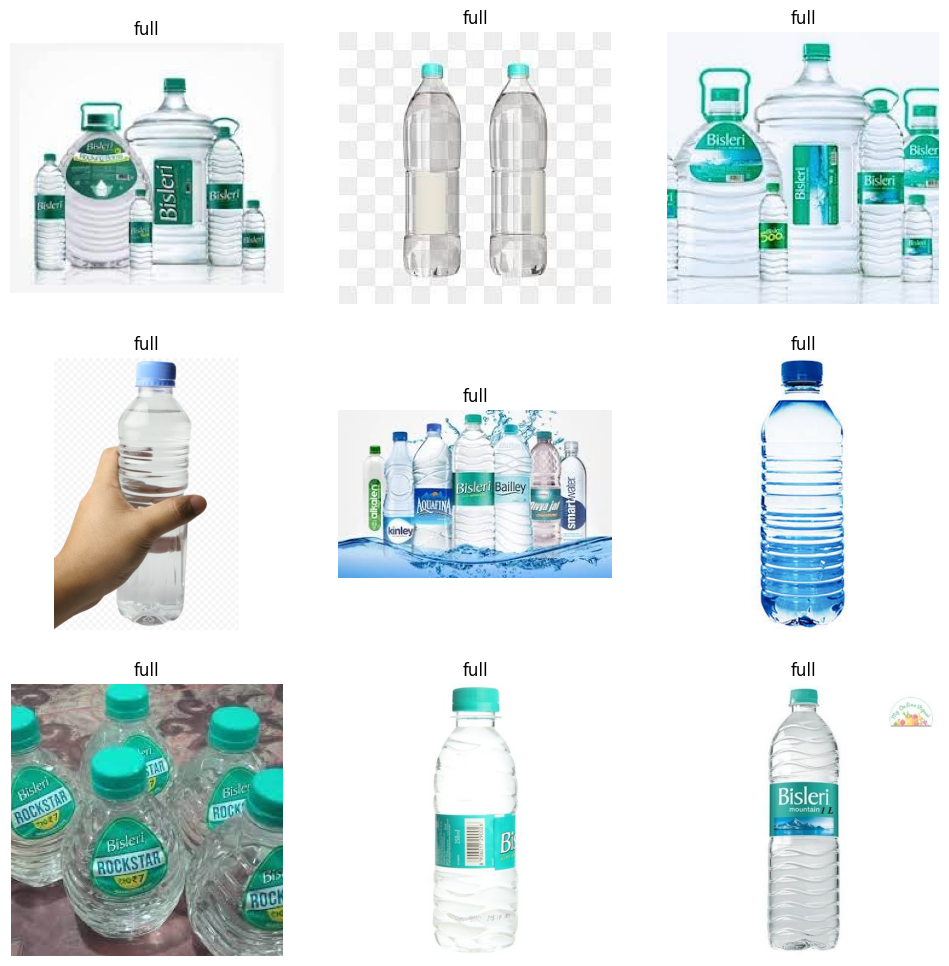

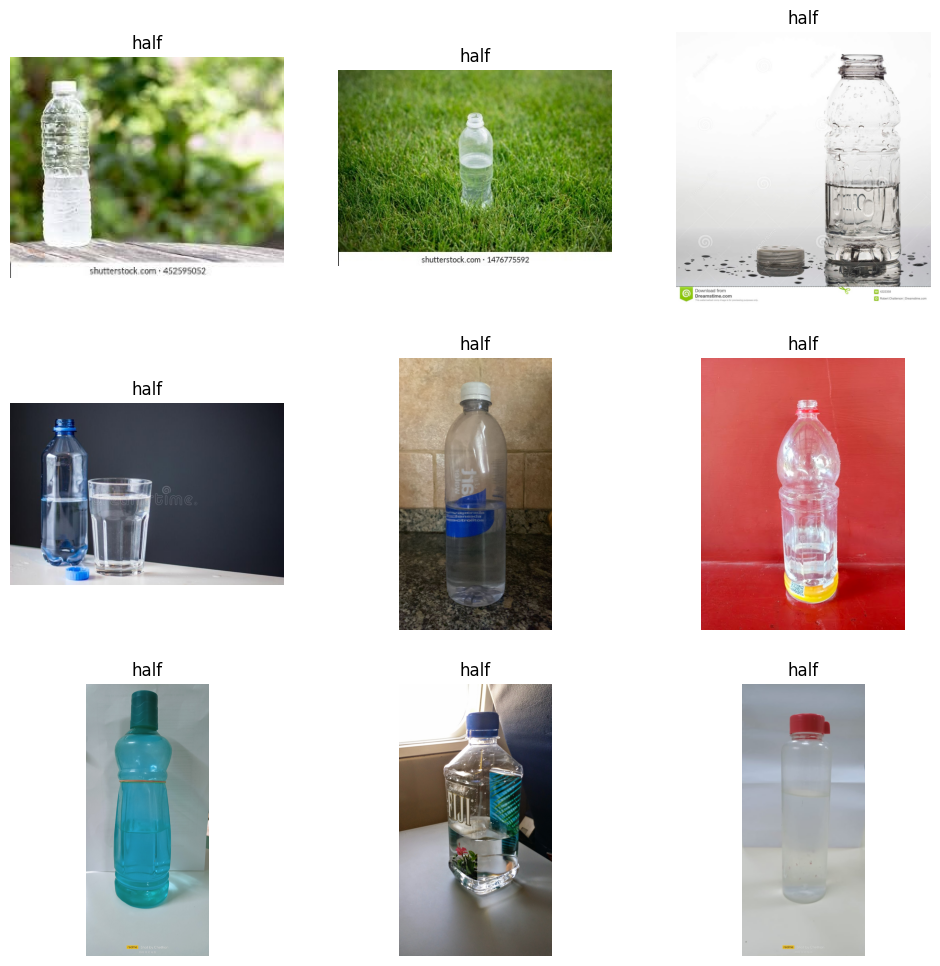

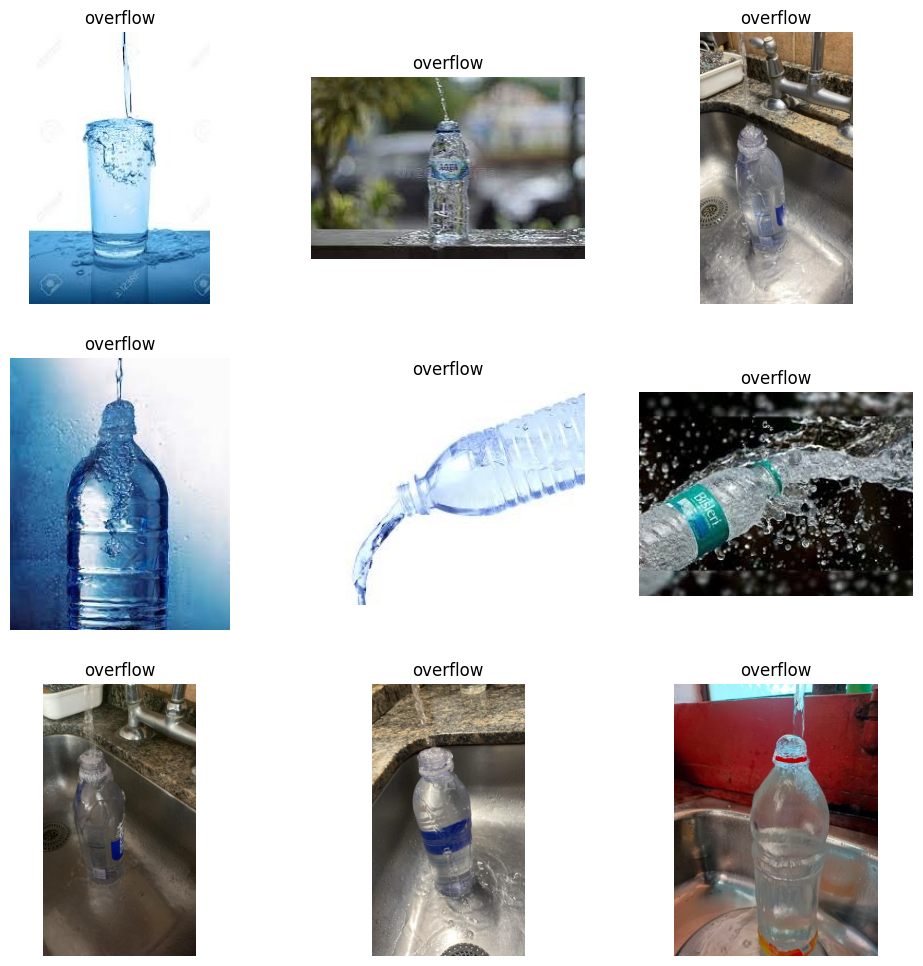

In [13]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def show_samples(df, label, n=9, cols=3, seed=0):
    paths = df[df["label"] == label]["path"].tolist()
    random.Random(seed).shuffle(paths)
    paths = paths[:n]

    rows = (len(paths) + cols - 1) // cols
    plt.figure(figsize=(4*cols, 4*rows))

    for i, p in enumerate(paths, start=1):
        img = Image.open(p).convert("RGB")
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(label)

    plt.show()

labels = sorted(df["label"].unique())
print("labels:", labels)

for lbl in labels:
    show_samples(df, lbl, n=9, cols=3, seed=42)


In [14]:
from sklearn.model_selection import train_test_split

#80% train, 10% val, 10% test
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

train_df = train_df.assign(split='train')
val_df = val_df.assign(split='val')
test_df = test_df.assign(split='test')

df_split = pd.concat([train_df, val_df, test_df], ignore_index=True)

df_split.head()

,path,label,split
0,..\data\full\images134_215_11zon.jpeg,full,train
1,..\data\full\images44_157_11zon.jpeg,full,train
2,..\data\full\607071a26c99ed00014a1add.png,full,train
3,..\data\full\images430_395_11zon.jpeg,full,train
4,..\data\full\bottled-water-bottle-plastic-groc...,full,train


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 224

# take any image from the train set
row = df_split[df_split["split"]=="train"].sample(1, random_state=0).iloc[0]
img = Image.open(row["path"]).convert("RGB")

# resize
img_r = img.resize((IMG_SIZE, IMG_SIZE))

# to numpy (H, W, C) in [0,1]
x = np.asarray(img_r).astype("float32") / 255.0

print("original size:", img.size)
print("resized size:", img_r.size)
print("array shape:", x.shape, "dtype:", x.dtype, "min/max:", x.min(), x.max())

plt.figure(figsize=(4,4))
plt.imshow(img_r)
plt.axis("off")
plt.title(row["label"])
plt.show()


In [ ]:
# =========================
# 0) Imports + config
# =========================
from pathlib import Path
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from PIL import Image
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 15
LR = 1e-3

# CPU for simplicity (switch to "cuda" if you ever get a GPU)
device = torch.device("cpu")

# =========================
# 1) Load df_split
# =========================

df_split = df_split.copy()
df_split["label"] = df_split["label"].str.lower().str.strip()
df_split["split"] = df_split["split"].str.lower().str.strip()

print("DF:", df_split.shape)
print("Splits:\n", df_split["split"].value_counts())
print("Labels:\n", df_split["label"].value_counts())

# label map
labels = sorted(df_split["label"].unique())
label_to_id = {lbl: i for i, lbl in enumerate(labels)}
id_to_label = {i: lbl for lbl, i in label_to_id.items()}
num_classes = len(labels)
print("label_to_id:", label_to_id)

# =========================
# 2) Transforms (preprocessing)
# =========================
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5), # data augmentation
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1), # data augmentation
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# =========================
# 3) Dataset + Dataloaders
# =========================
class ImageDFDataset(Dataset):
    def __init__(self, df, label_to_id, tfms):
        self.df = df.reset_index(drop=True)
        self.label_to_id = label_to_id
        self.tfms = tfms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGBA").convert("RGB")
        x = self.tfms(img)
        y = self.label_to_id[row["label"]]
        return x, y

train_df = df_split[df_split["split"] == "train"]
val_df   = df_split[df_split["split"] == "val"]
test_df  = df_split[df_split["split"] == "test"]

train_ds = ImageDFDataset(train_df, label_to_id, train_tfms)
val_ds   = ImageDFDataset(val_df,   label_to_id, eval_tfms)
test_ds  = ImageDFDataset(test_df,  label_to_id, eval_tfms)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# sanity check
xb, yb = next(iter(train_dl))
print("sanity xb:", xb.shape, "yb:", yb.shape)

# =========================
# 4) Model (pretrained ResNet18) + freeze backbone
# =========================
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)

# freeze everything except fc
for p in model.parameters():
    p.requires_grad = False
for p in model.fc.parameters():
    p.requires_grad = True

model = model.to(device)

# =========================
# 5) Train loop + Eval loop
# =========================
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=LR)

def run_epoch(model, dl, train: bool):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_n = 0

    all_preds = []
    all_true = []

    for xb, yb in dl:
        xb = xb.to(device)
        yb = yb.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            logits = model(xb)
            loss = loss_fn(logits, yb)

            if train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        total_n += xb.size(0)

        all_preds.append(preds.detach().cpu().numpy())
        all_true.append(yb.detach().cpu().numpy())

    avg_loss = total_loss / total_n
    acc = total_correct / total_n
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_true)
    return avg_loss, acc, y_true, y_pred

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, _, _ = run_epoch(model, train_dl, train=True)
    va_loss, va_acc, _, _ = run_epoch(model, val_dl,   train=False)
    print(f"Epoch {epoch}/{EPOCHS} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")

# =========================
# 6) Final test evaluation + confusion matrix + report
# =========================
te_loss, te_acc, y_true, y_pred = run_epoch(model, test_dl, train=False)
print(f"\nTEST loss {te_loss:.4f} acc {te_acc:.4f}\n")

cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
print("Confusion matrix (rows=true, cols=pred):\n", cm, "\n")

print("Classification report:\n")
print(classification_report(
    y_true, y_pred,
    target_names=[id_to_label[i] for i in range(num_classes)],
    digits=3
))

# =========================
# 7) Save artifact (model + pipeline metadata)
# =========================
out_dir = (Path.cwd() / ".." / "artifacts").resolve()
out_dir.mkdir(parents=True, exist_ok=True)
artifact_path = out_dir / "model_resnet18_v1.pt"

torch.save({
    "model_name": "resnet18",
    "img_size": IMG_SIZE,
    "imagenet_mean": IMAGENET_MEAN,
    "imagenet_std": IMAGENET_STD,
    "label_to_id": label_to_id,
    "state_dict": model.state_dict(),
}, artifact_path)

print("Saved artifact:", artifact_path)


In [17]:
artifact = {
    'model_name': 'resnet18',
    'num_classes': num_classes,
    'label_to_id': label_to_id,
    'img_size': 224,
    'imagenet_mean': IMAGENET_MEAN,
    'imagenet_std': IMAGENET_STD,
    'state_dict': model.state_dict(),
}

out_dir = Path('../artifacts')
artifact_path = out_dir / 'waterbottle_resnet18_v1.pt'

torch.save(artifact, artifact_path)
print('Saved:', artifact_path.resolve())

Saved: C:\Users\mateo\OneDrive\Documentos\proyecto2\artifacts\waterbottle_resnet18_v1.pt


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from torchvision.models import resnet18

def load_model(artifact_path: str):
    ckpt = torch.load(artifact_path, map_location="cpu")

    model = resnet18(weights=None)  # no imagenet weights; we'll load yours
    model.fc = nn.Linear(model.fc.in_features, ckpt["num_classes"])
    model.load_state_dict(ckpt["state_dict"])
    model.eval()

    # rebuild inference transforms
    tfm = transforms.Compose([
        transforms.Resize((ckpt["img_size"], ckpt["img_size"])),
        transforms.ToTensor(),
        transforms.Normalize(tuple(ckpt["imagenet_mean"]), tuple(ckpt["imagenet_std"])),
    ])

    # invert the mapping
    id_to_label = {v: k for k, v in ckpt["label_to_id"].items()}
    return model, tfm, id_to_label

def predict_image(model, tfm, id_to_label, image_path: str):
    img = Image.open(image_path).convert("RGBA").convert("RGB")
    x = tfm(img).unsqueeze(0)  # [1,3,224,224]

    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1)[0]     # [3]
        conf, pred_id = probs.max(dim=0)

    return {
        "pred_label": id_to_label[int(pred_id)],
        "confidence": float(conf),
        "probs": {id_to_label[i]: float(probs[i]) for i in range(len(id_to_label))}
    }


In [9]:
model2, tfm2, id_to_label2 = load_model("../artifacts/waterbottle_resnet18_v1.pt")
result = predict_image(model2, tfm2, id_to_label2, "../data/prueba/prueba9.jpeg")
result


{'pred_label': 'half',
 'confidence': 0.7840978503227234,
 'probs': {'full': 0.13274620473384857,
  'half': 0.7840978503227234,
  'overflow': 0.08315596729516983}}

In [ ]:
import matplotlib.pyplot as plt
import torch

MEAN = torch.tensor(IMAGENET_MEAN).view(3,1,1)
STD  = torch.tensor(IMAGENET_STD).view(3,1,1)

def show_model_input(image_path):
    img = Image.open(image_path).convert("RGBA").convert("RGB")
    x = tfm2(img)  # [3,224,224] normalized

    # de-normalize for visualization
    x_vis = (x * STD + MEAN).clamp(0,1)
    x_vis = x_vis.permute(1,2,0).numpy()

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1); plt.imshow(img); plt.axis("off"); plt.title("Original")
    plt.subplot(1,2,2); plt.imshow(x_vis); plt.axis("off"); plt.title("Model input (224x224)")
    plt.show()

show_model_input("../data/prueba/prueba9.jpeg")
